First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   37    male  34.100       4.0    yes  southwest  40182.24600
1   18    male  34.430       0.0     no  southeast   1137.46970
2   23  female  36.670       2.0    yes  northeast  38511.62830
3   32    male  35.200       2.0     no  southwest   4670.64000
4   58  female  32.395       1.0     no  northeast  13019.16105

Shape of Dataset:
(1057, 7)

Data Types:
age           int64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age          0
sex         10
bmi          0
children     0
smoker       5
region       4
charges      0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1057.000000  1057.000000  1057.000000   1057.000000
mean     39.045412    30.720894     1.087039  13190.628947
std      14.080391     6.204655     1.213869  11980.773703
min      18.0

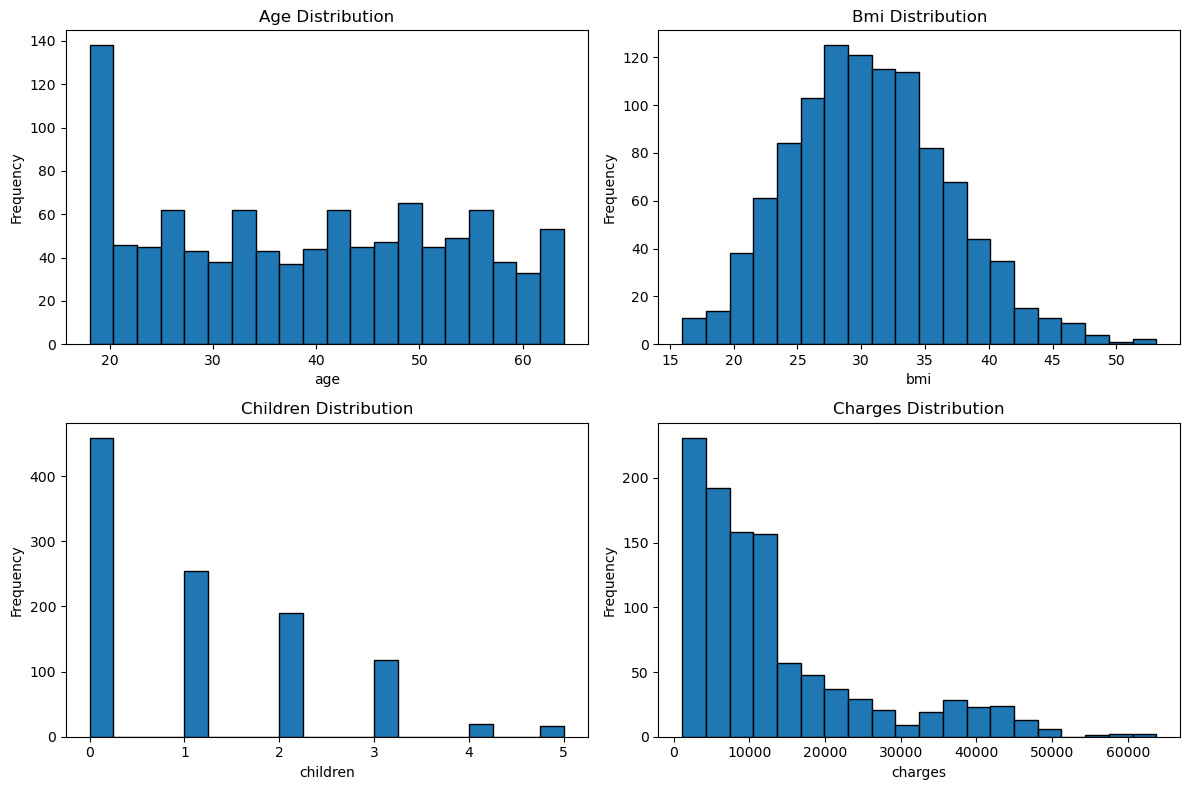

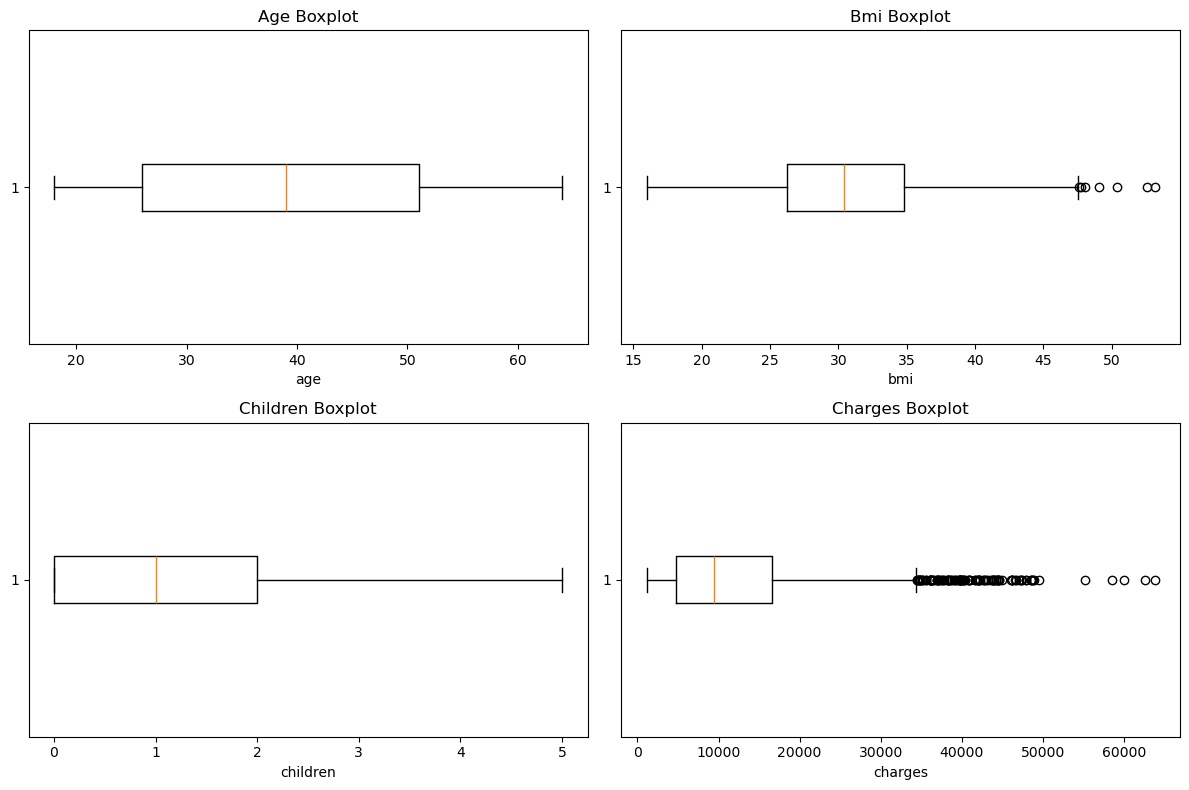

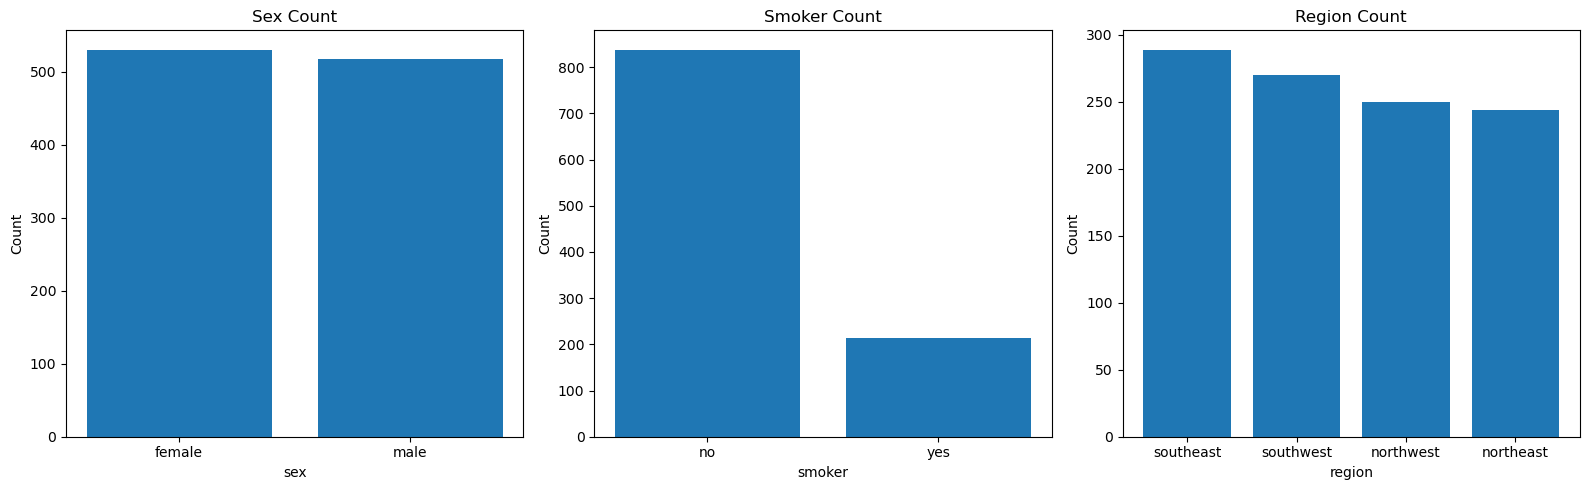

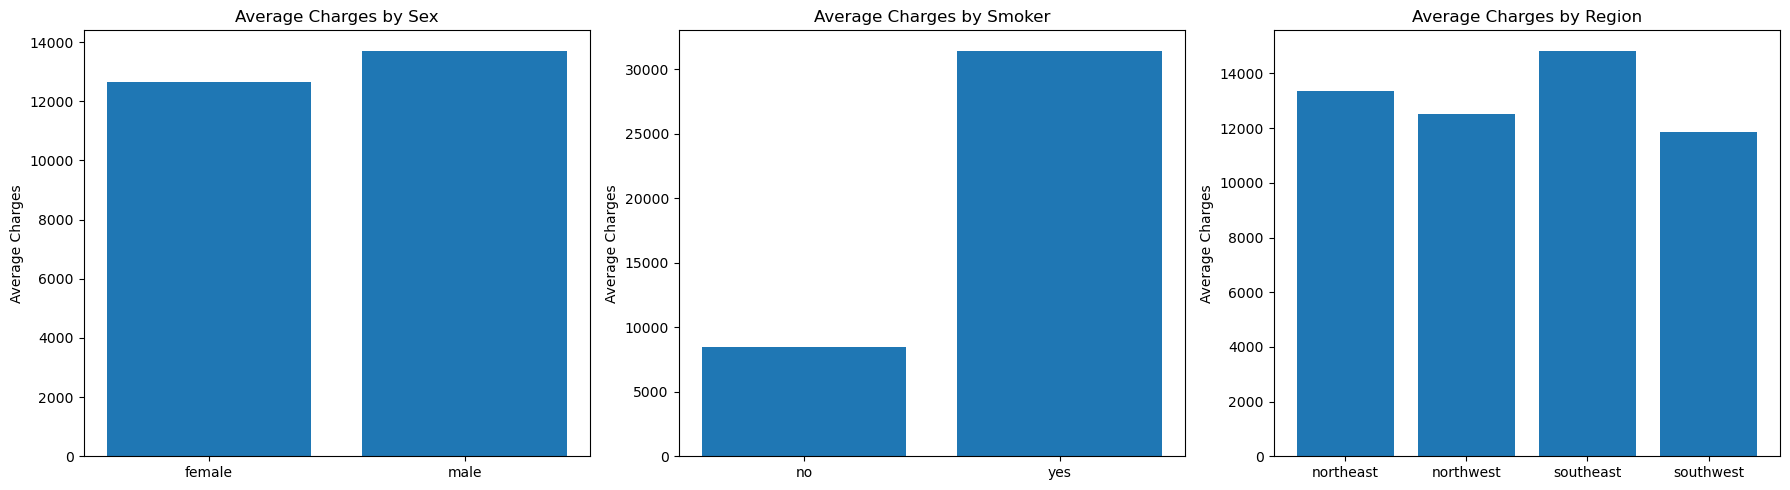

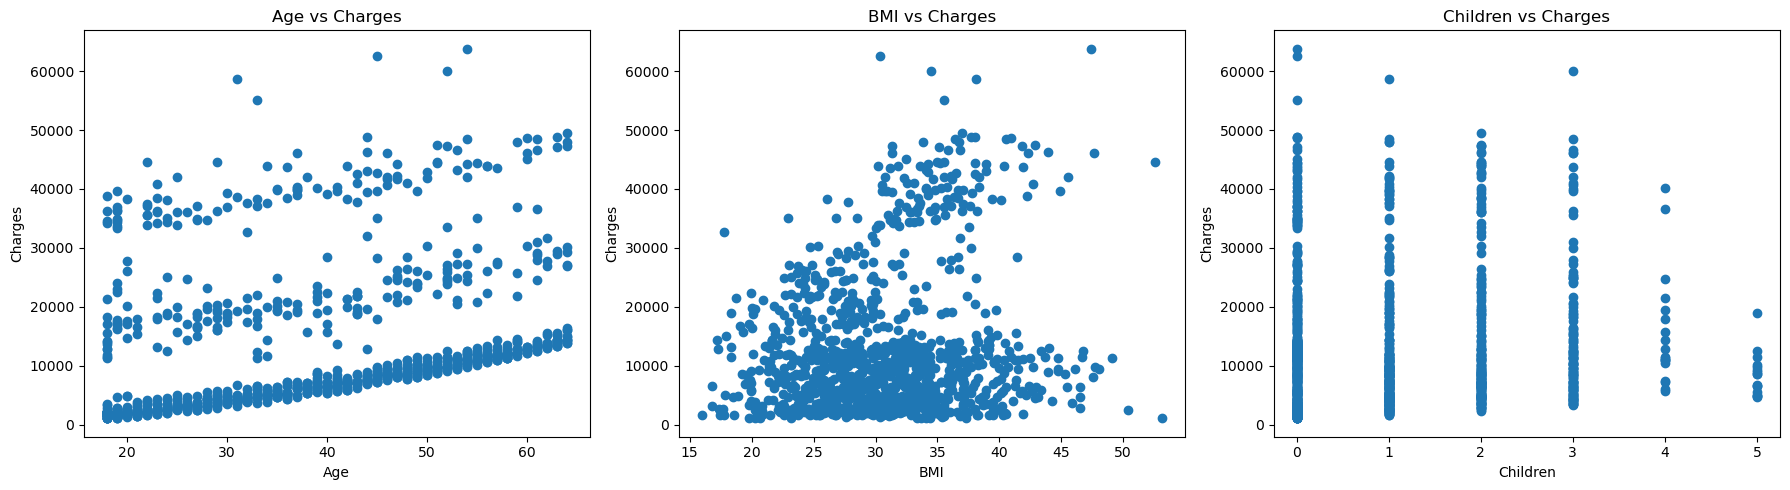

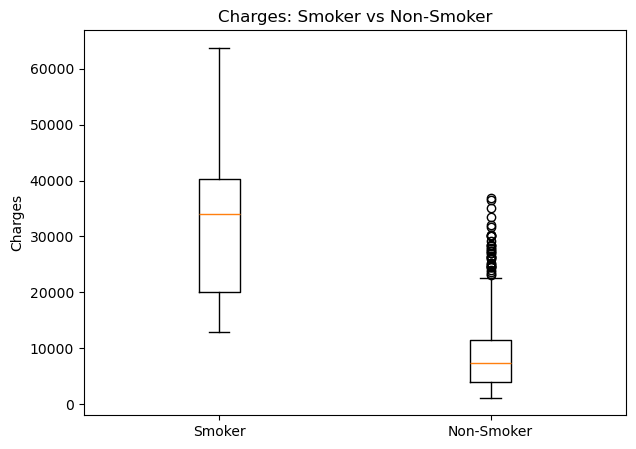

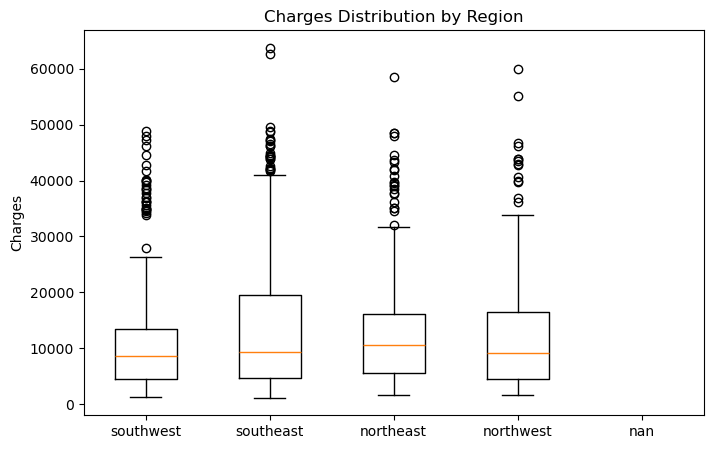

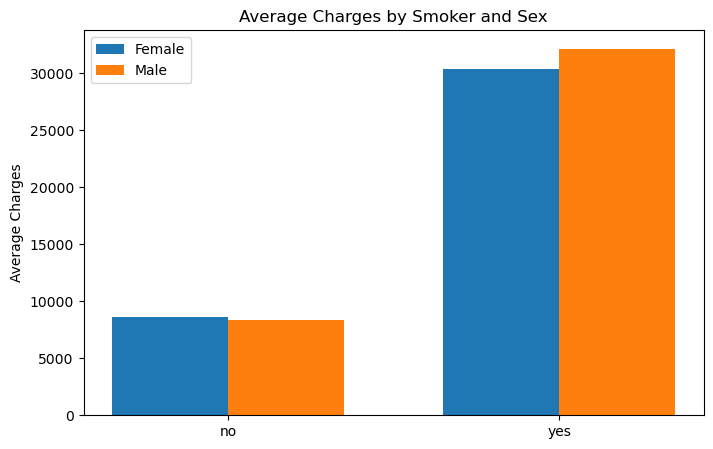

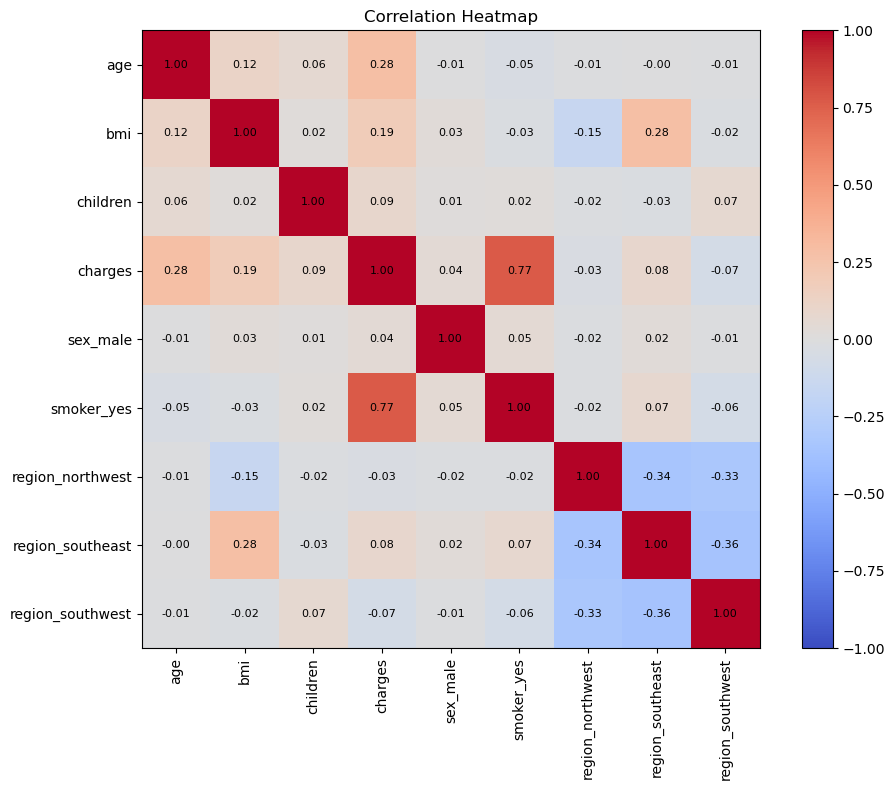

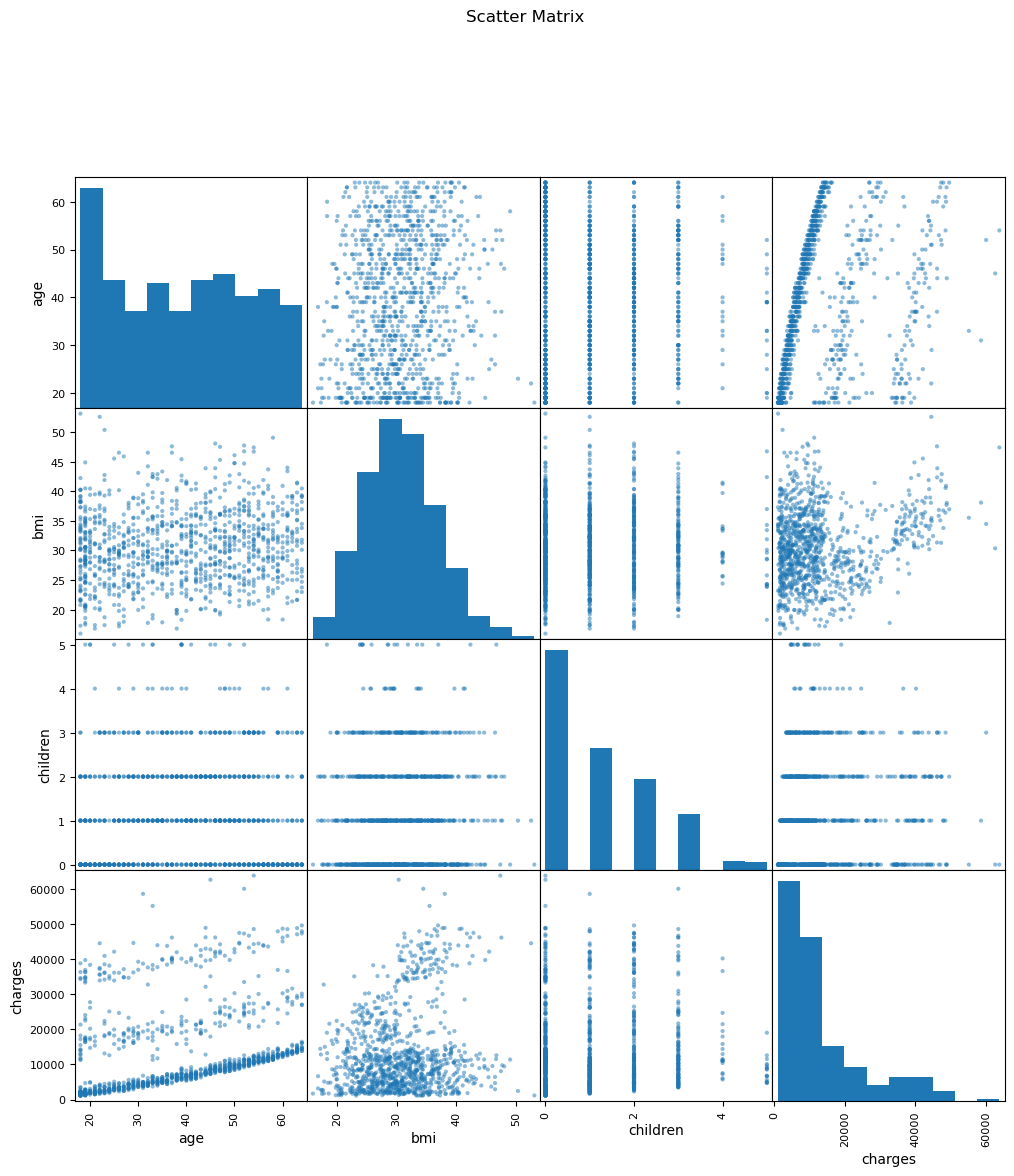

C:\Users\SAYAN SHYAMAL\AppData\Local\Temp\ipykernel_30688\1894102854.py:228: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_avg = df.groupby('bmi_category')['charges'].mean()


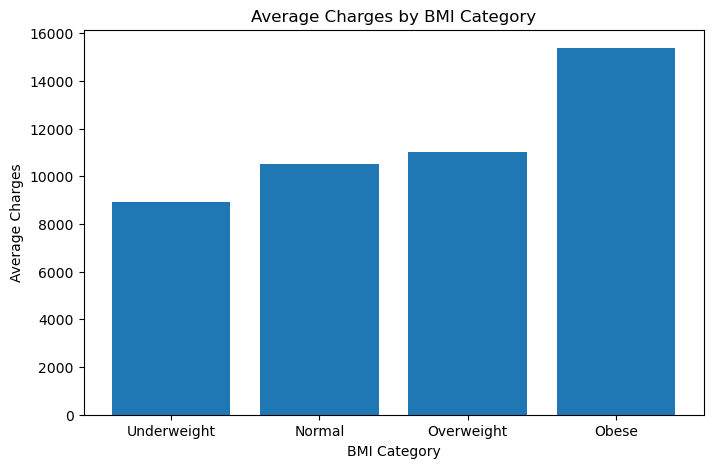

C:\Users\SAYAN SHYAMAL\AppData\Local\Temp\ipykernel_30688\1894102854.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg = df.groupby('age_group')['charges'].mean()


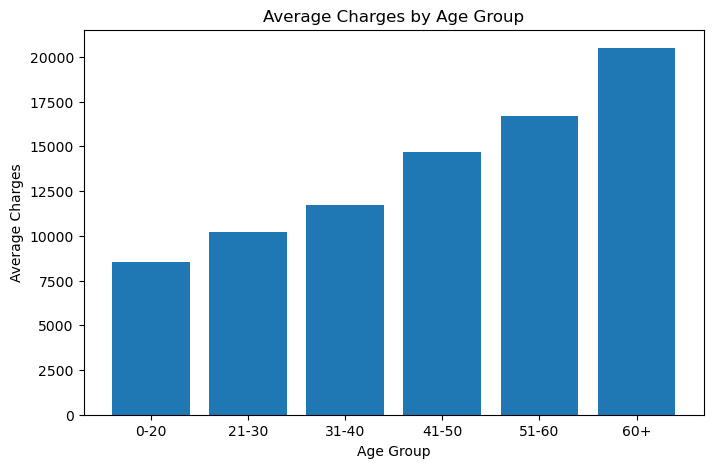

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load Dataset
# =========================
df = pd.read_csv("hospital data.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert numeric columns properly
numeric_cols = ['age', 'bmi', 'children', 'charges']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows having missing numeric values
df = df.dropna(subset=numeric_cols)

# =========================
# Basic Information
# =========================
print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# =========================
# 1. Histograms
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col], bins=20, edgecolor='black')
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# =========================
# 2. Boxplots
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(f'{col.capitalize()} Boxplot')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

# =========================
# 3. Count Plots for Categorical Columns
# =========================
categorical_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f'{col.capitalize()} Count')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# =========================
# 4. Average Charges by Category
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sex_avg = df.groupby('sex')['charges'].mean()
axes[0].bar(sex_avg.index.astype(str), sex_avg.values)
axes[0].set_title('Average Charges by Sex')
axes[0].set_ylabel('Average Charges')

smoker_avg = df.groupby('smoker')['charges'].mean()
axes[1].bar(smoker_avg.index.astype(str), smoker_avg.values)
axes[1].set_title('Average Charges by Smoker')
axes[1].set_ylabel('Average Charges')

region_avg = df.groupby('region')['charges'].mean()
axes[2].bar(region_avg.index.astype(str), region_avg.values)
axes[2].set_title('Average Charges by Region')
axes[2].set_ylabel('Average Charges')

plt.tight_layout()
plt.show()

# =========================
# 5. Scatter Plots vs Charges
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['age'], df['charges'])
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')

axes[1].scatter(df['bmi'], df['charges'])
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

axes[2].scatter(df['children'], df['charges'])
axes[2].set_title('Children vs Charges')
axes[2].set_xlabel('Children')
axes[2].set_ylabel('Charges')

plt.tight_layout()
plt.show()

# =========================
# 6. Charges for Smokers vs Non-Smokers
# =========================
smoker_yes = df[df['smoker'] == 'yes']['charges']
smoker_no = df[df['smoker'] == 'no']['charges']

plt.figure(figsize=(7, 5))
plt.boxplot([smoker_yes, smoker_no], tick_labels=['Smoker', 'Non-Smoker'])
plt.title('Charges: Smoker vs Non-Smoker')
plt.ylabel('Charges')
plt.show()

# =========================
# 7. Charges by Region
# =========================
regions = df['region'].unique()
region_data = [df[df['region'] == region]['charges'] for region in regions]

plt.figure(figsize=(8, 5))
plt.boxplot(region_data, tick_labels=regions)
plt.title('Charges Distribution by Region')
plt.ylabel('Charges')
plt.show()

# =========================
# 8. Average Charges by Smoker and Sex
# =========================
grouped = df.groupby(['smoker', 'sex'])['charges'].mean().unstack()

x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, grouped['female'], width, label='Female')
plt.bar(x + width/2, grouped['male'], width, label='Male')

plt.xticks(x, grouped.index)
plt.ylabel('Average Charges')
plt.title('Average Charges by Smoker and Sex')
plt.legend()
plt.show()

# =========================
# 9. Correlation Heatmap with Values
# =========================
df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Write values inside each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

plt.colorbar(im)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# =========================
# 10. Scatter Matrix
# =========================
pd.plotting.scatter_matrix(
    df[numeric_cols],
    figsize=(12, 12),
    diagonal='hist'
)
plt.suptitle("Scatter Matrix", y=1.02)
plt.show()

# =========================
# 11. BMI Category vs Average Charges
# =========================
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

bmi_avg = df.groupby('bmi_category')['charges'].mean()

plt.figure(figsize=(8, 5))
plt.bar(bmi_avg.index.astype(str), bmi_avg.values)
plt.title('Average Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Charges')
plt.show()

# =========================
# 12. Age Group vs Average Charges
# =========================
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['0-20', '21-30', '31-40', '41-50', '51-60', '60+']
)

age_avg = df.groupby('age_group')['charges'].mean()

plt.figure(figsize=(8, 5))
plt.bar(age_avg.index.astype(str), age_avg.values)
plt.title('Average Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Charges')
plt.show()